# Daily Challenge: Strategic Analysis of Superstore Performance

Notebook complet (analyse + visualisation + insights).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from ipywidgets import interact, Dropdown, IntSlider
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')


In [3]:

df = pd.read_csv('superstore_dataset.csv', encoding='latin-1')

print("Dataset Shape:", df.shape)
print(df.columns.tolist())

df.info()
df.describe()

Dataset Shape: (9994, 21)
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null  

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


## 1. Data Cleaning

In [4]:
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()

print(df.isnull().sum())

if 'Postal Code' in df.columns:
    df['Postal Code'] = df['Postal Code'].fillna(0)

date_columns = ['Order Date', 'Ship Date']
for col in date_columns:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col])

print(df[date_columns].dtypes if all(c in df.columns for c in date_columns) else "No date columns")


Duplicate rows: 0
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64
Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object


## Feature Engineering

In [5]:
df['Profit Margin'] = (df['Profit'] / df['Sales']) * 100
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month
df['Order Month-Year'] = df['Order Date'].dt.to_period('M')

df.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Profit Margin,Order Year,Order Month,Order Month-Year
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,16.00,2016,11,2016-11
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,30.00,2016,11,2016-11
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,47.00,2016,6,2016-06
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,-40.00,2015,10,2015-10
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,11.25,2015,10,2015-10


## Time Series Analysis

In [6]:
monthly_sales = df.groupby(['Order Month-Year', 'Category'])['Sales'].sum().reset_index()
monthly_sales['Date'] = monthly_sales['Order Month-Year'].dt.to_timestamp()

def plot_monthly_sales(category='All'):
    plt.figure(figsize=(12,6))
    if category == 'All':
        total = df.groupby('Order Month-Year')['Sales'].sum()
        plt.plot(total.index.to_timestamp(), total.values)
        plt.title("Monthly Sales - All Categories")
    else:
        data = monthly_sales[monthly_sales['Category']==category]
        plt.plot(data['Date'], data['Sales'])
        plt.title(f"Monthly Sales - {category}")
    plt.xticks(rotation=45)
    plt.grid()
    plt.show()

Dropdown(options=['All']+list(df['Category'].unique()))


Dropdown(options=('All', 'Furniture', 'Office Supplies', 'Technology'), value='All')

## Geographic Analysis

In [7]:
state_sales = df.groupby('State')['Sales'].sum().sort_values()

def plot_top_states(top_n=10):
    top = state_sales.tail(top_n)
    plt.figure(figsize=(10,5))
    plt.barh(top.index, top.values)
    plt.title(f"Top {top_n} States")
    plt.show()

IntSlider(min=5,max=25,value=10)


IntSlider(value=10, max=25, min=5)

## Seaborn Insights

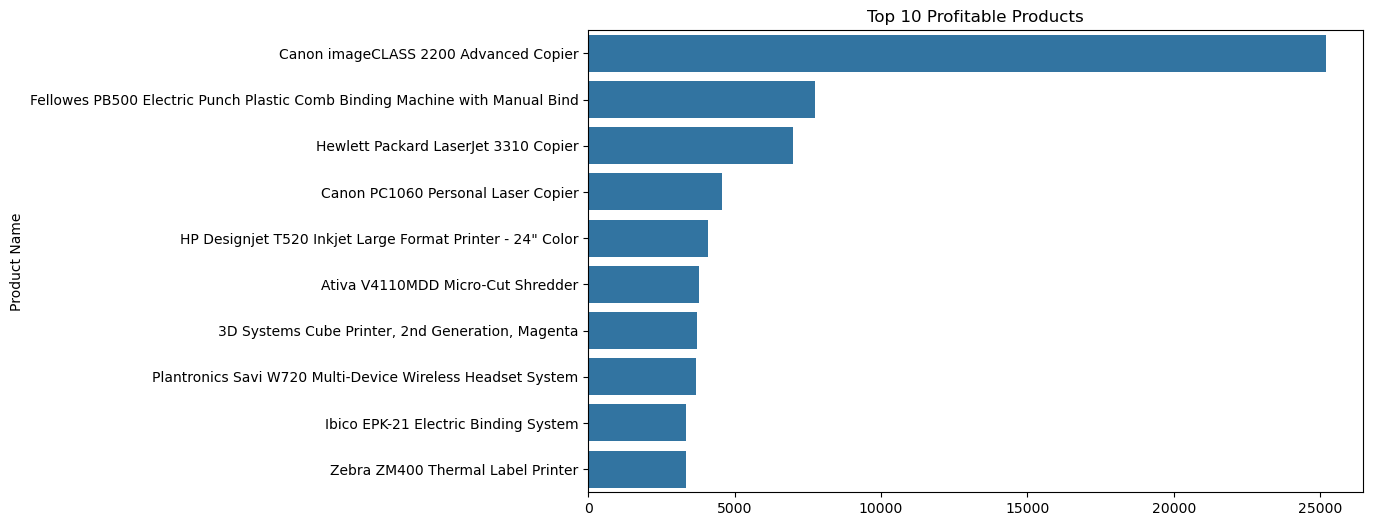

In [8]:
product_profit = df.groupby('Product Name')['Profit'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=product_profit.values, y=product_profit.index)
plt.title("Top 10 Profitable Products")
plt.show()


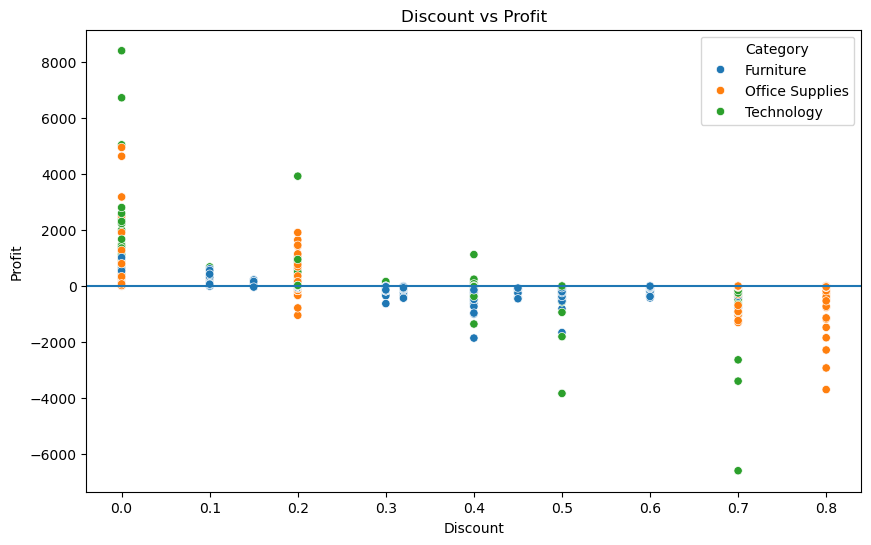

In [9]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Discount', y='Profit', hue='Category')
plt.axhline(0)
plt.title("Discount vs Profit")
plt.show()


## Executive Summary

In [10]:
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
margin = (total_profit/total_sales)*100

print("Sales:", total_sales)
print("Profit:", total_profit)
print("Margin:", margin)


Sales: 2297200.8603000003
Profit: 286397.0217
Margin: 12.467217240315604
